# "Reducing Hallucination in Structured Outputs via RAG"
# Béchard & Ayala, NAACL Industry Track 2024
#
# Paper's task  : NL → JSON workflow with step names from a known lexicon
# Our adaptation: NL → JSON intent+slots with slot types from ATIS vocabulary
#
# Key parallel:
#   Paper steps/tables  ↔  ATIS slot-types / intent labels
#   Paper hallucination ↔  generating a slot/intent NOT in the ATIS vocabulary
#
# Paper's 3 contributions we reproduce:
#   1. Fine-tuned retriever (siamese encoder + contrastive loss) outperforms off-the-shelf
#   2. RAG reduces hallucination vs baseline LLM
#   3. Smaller RAG model competitive with larger baseline model
#
# Our novel gap (NOT in paper):
#   Ablation over retrieval size K = {1, 3, 5, 10}
#   Paper used a fixed K — never studied its effect

# Install Dependencies

In [2]:
!pip install datasets transformers>=4.41 sentence-transformers>=3.0 peft>=0.11 faiss-cpu accelerate

# Imports & Config

In [3]:
import json, random, gc
import torch
import numpy as np
from datasets import load_dataset, Dataset as HFDataset
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    get_cosine_schedule_with_warmup,
)
from sentence_transformers import (
    SentenceTransformer,
    SentenceTransformerTrainingArguments,
    SentenceTransformerTrainer,
    models, losses,
)
from sentence_transformers.training_args import BatchSamplers
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from peft import get_peft_model, LoraConfig, TaskType
import faiss
from tqdm import tqdm
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

CFG = {
    # LLM: CodeT5-base (220M), code/JSON-aware, fits T4 with LoRA
    "llm"           : "Salesforce/codet5-base",
    # Retriever base: same family as paper (all-mpnet-base-v2, 110M)
    "retriever_base": "sentence-transformers/all-mpnet-base-v2",
    "top_k"         : 5,
    "max_src_len"   : 256,
    "max_tgt_len"   : 128,
    # LLM hyperparams — Appendix A of paper
    "llm_lr"        : 5e-4,
    "llm_batch"     : 16,
    "llm_epochs"    : 6,
    "warmup_steps"  : 100,
    "lora_r"        : 16,
    "lora_alpha"    : 16,
    "lora_dropout"  : 0.05,
    # Retriever hyperparams — Appendix A of paper
    "ret_lr"        : 2e-5,
    "ret_batch"     : 64,
    "ret_epochs"    : 5,
    # Eval batch size for fast batched generation
    "eval_batch"    : 32,
    "seed"          : 42,
}

random.seed(CFG["seed"])
np.random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])

Running on: cuda
GPU : Tesla T4
VRAM: 15.6 GB


/tmp/ipykernel_11611/439159022.py:9: DeprecationWarning: Importing from 'sentence_transformers.models' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.modules' instead.
  from sentence_transformers import (
/tmp/ipykernel_11611/439159022.py:9: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import (
/tmp/ipykernel_11611/439159022.py:15: DeprecationWarning: Importing from 'sentence_transformers.training_args' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.training_args' instead.
  from sentence_transformers.training_args import BatchSamplers


Load ATIS & Extract Vocabulary

In [4]:
raw = load_dataset("tuetschek/atis")
print(raw["train"].column_names)
print(raw["train"].features)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


atis_train.csv: 0.00B [00:00, ?B/s]

atis_test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/4978 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/893 [00:00<?, ? examples/s]

['id', 'intent', 'text', 'slots']
{'id': Value('int64'), 'intent': Value('string'), 'text': Value('string'), 'slots': Value('string')}


In [5]:
import json
from datasets import load_dataset

def parse_slots(text: str, slots_str: str) -> dict:
    """
    Parse BIO-tagged slot string aligned with utterance tokens.
    B-<slot> starts a slot, I-<slot> continues it, O = outside.
    """
    slots = {}
    if not slots_str or not isinstance(slots_str, str):
        return slots

    words = text.strip().split()
    tags  = slots_str.strip().split()

    current_slot = None
    current_val  = []

    for word, tag in zip(words, tags):
        if tag.startswith("B-"):
            if current_slot:                          # flush previous
                slots[current_slot] = " ".join(current_val)
            current_slot = tag[2:]                    # strip "B-"
            current_val  = [word]
        elif tag.startswith("I-") and current_slot:
            current_val.append(word)
        else:                                         # "O" tag
            if current_slot:
                slots[current_slot] = " ".join(current_val)
            current_slot = None
            current_val  = []

    if current_slot:                                  # flush last slot
        slots[current_slot] = " ".join(current_val)

    return slots


def load_atis():
    raw = load_dataset("tuetschek/atis")

    def preprocess(ex):
        text   = ex["text"]
        intent = ex["intent"]
        slots  = parse_slots(text, ex["slots"])       # <-- pass text too

        return {
            "text"  : text,
            "intent": intent,
            "slots" : slots,
            "output": json.dumps({"intent": intent, "slots": slots})
        }

    splits = {k: [preprocess(ex) for ex in raw[k]] for k in raw.keys()}

    intent_vocab = sorted({ex["intent"] for ex in splits["train"]})
    slot_vocab   = sorted({k for ex in splits["train"] for k in ex["slots"]})

    print(f"Train: {len(splits['train'])}")
    if "validation" in splits:
        print(f"Validation: {len(splits['validation'])}")
    print(f"Test:  {len(splits['test'])}")
    print(f"Known intents:    {len(intent_vocab)}")
    print(f"Known slot types: {len(slot_vocab)}")
    print("\nSample input:",  splits["train"][0]["text"])
    print("Sample output:", splits["train"][0]["output"])

    return (
        splits["train"],
        splits.get("validation", []),
        splits["test"],
        intent_vocab,
        slot_vocab,
    )

train_data, val_data, test_data, INTENT_VOCAB, SLOT_VOCAB = load_atis()

Train: 4978
Test:  893
Known intents:    22
Known slot types: 79

Sample input: i want to fly from boston at 838 am and arrive in denver at 1110 in the morning
Sample output: {"intent": "flight", "slots": {"fromloc.city_name": "boston", "depart_time.time": "838 am", "toloc.city_name": "denver", "arrive_time.time": "1110", "arrive_time.period_of_day": "morning"}}


In [6]:
# If no validation split, carve 10% off training data
if not val_data:
    split_idx = int(0.9 * len(train_data))
    val_data   = train_data[split_idx:]
    train_data = train_data[:split_idx]
    print(f"No validation split found — using last {len(val_data)} train examples as val")
    print(f"Adjusted train size: {len(train_data)}")

No validation split found — using last 498 train examples as val
Adjusted train size: 4480


# Fine-tune Retriever with Contrastive Loss  (Section 3.1)

In [7]:
# Paper: siamese encoder trained on (query, step_JSON) positive pairs
#        with random negative sampling
# Us:    siamese encoder trained on (query, slot_type) positive pairs
#        with random negatives from ATIS slot vocabulary
# ================================================================
def build_retriever_hf_dataset(data: list, slot_vocab: list,
                               intent_vocab: list) -> HFDataset:
    """
    Triplet dataset for contrastive retriever training.
    Positive pairs: (utterance, slot_type) for each slot in the utterance.
    Negative pairs: random slot type NOT present in the utterance.
    Also adds (utterance, intent) pairs so the intent index trains well too.
    Falls back to intent-only pairs for examples that have no slots.
    """
    anchors, positives, negatives = [], [], []
    for ex in data:
        present_slots   = set(ex["slots"].keys())
        absent_slots    = [s for s in slot_vocab   if s not in present_slots]
        absent_intents  = [i for i in intent_vocab if i != ex["intent"]]

        # Slot-level pairs (main retrieval signal)
        if present_slots and absent_slots:
            for slot_type in present_slots:
                anchors.append(ex["text"])
                positives.append(slot_type)
                negatives.append(random.choice(absent_slots))

        # Intent-level pairs (always added — every example has an intent)
        if absent_intents:
            anchors.append(ex["text"])
            positives.append(ex["intent"])
            negatives.append(random.choice(absent_intents))

    return HFDataset.from_dict({
        "anchor"  : anchors,
        "positive": positives,
        "negative": negatives,
    })


print("\nBuilding retriever training pairs...")
ret_dataset = build_retriever_hf_dataset(train_data, SLOT_VOCAB, INTENT_VOCAB)
print(f"Retriever triplets: {len(ret_dataset)}")
assert len(ret_dataset) > 0, "Dataset is empty — check SLOT_VOCAB and INTENT_VOCAB"

# Siamese encoder: Transformer + MeanPool + L2Normalize (paper eq. 1-3)
word_emb  = models.Transformer(CFG["retriever_base"], max_seq_length=64)
pooling   = models.Pooling(word_emb.get_embedding_dimension(),
                           pooling_mode="mean")
normalize = models.Normalize()
ret_model = SentenceTransformer(modules=[word_emb, pooling, normalize], device=DEVICE)

triplet_loss = losses.TripletLoss(model=ret_model)

# Compute max_steps explicitly so trainer knows dataloader length
steps_per_epoch = len(ret_dataset) // CFG["ret_batch"]
total_ret_steps = steps_per_epoch * CFG["ret_epochs"]
warmup_ret_steps = max(1, int(0.1 * total_ret_steps))

ret_args = SentenceTransformerTrainingArguments(
    output_dir                  = "retriever_ckpt",
    max_steps                   = total_ret_steps,   # explicit steps avoids length error
    per_device_train_batch_size = CFG["ret_batch"],
    learning_rate               = CFG["ret_lr"],
    warmup_steps                = warmup_ret_steps,  # use steps not ratio (Transformers v5+)
    save_strategy               = "no",
    logging_steps               = 50,
    fp16                        = (DEVICE == "cuda"),
)

ret_trainer = SentenceTransformerTrainer(
    model         = ret_model,
    args          = ret_args,
    train_dataset = ret_dataset,
    loss          = triplet_loss,
)

print(f"\nFine-tuning retriever for {CFG['ret_epochs']} epochs...")
ret_trainer.train()
ret_model.save_pretrained("retriever_ckpt/final")
print("Retriever saved to retriever_ckpt/final")


Building retriever training pairs...
Retriever triplets: 18862


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...


Fine-tuning retriever for 5 epochs...


Step,Training Loss
50,4.837249
100,4.205017
150,3.822756
200,3.687529
250,3.703477
300,3.676293
350,3.677718
400,3.706955
450,3.678599
500,3.692517


Step,Training Loss
50,4.837249
100,4.205017
150,3.822756
200,3.687529
250,3.703477
300,3.676293
350,3.677718
400,3.706955
450,3.678599
500,3.692517


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Retriever saved to retriever_ckpt/final


# Build FAISS Indices (Section 3.1)

In [10]:
raw = load_dataset("tuetschek/atis")
sample = raw["train"][0]
print("Keys:", sample.keys())
print("Slots value:", sample["slots"])
print("Slots type:", type(sample["slots"]))
print("Text:", sample["text"])
print("Intent:", sample["intent"])

Keys: dict_keys(['id', 'intent', 'text', 'slots'])
Slots value: O O O O O B-fromloc.city_name O B-depart_time.time I-depart_time.time O O O B-toloc.city_name O B-arrive_time.time O O B-arrive_time.period_of_day
Slots type: <class 'str'>
Text: i want to fly from boston at 838 am and arrive in denver at 1110 in the morning
Intent: flight


In [9]:
# Paper builds TWO separate indices: one for steps, one for tables.
# We build TWO separate indices: one for slot types, one for intents.
# ================================================================
print("\nBuilding FAISS indices...")


def build_faiss_index(items: list, model: SentenceTransformer) -> faiss.IndexFlatIP:
    assert len(items) > 0, f"Vocabulary is empty — cannot build FAISS index"
    embs = model.encode(items, batch_size=128,
                        show_progress_bar=False, convert_to_numpy=True)
    # embs shape must be (N, dim) — if it's 1D the encode failed
    if embs.ndim == 1:
        embs = embs.reshape(1, -1)
    idx  = faiss.IndexFlatIP(embs.shape[1])
    idx.add(embs.astype(np.float32))
    return idx


# Debug: confirm vocabularies are populated before indexing
print(f"SLOT_VOCAB size:   {len(SLOT_VOCAB)}")
print(f"INTENT_VOCAB size: {len(INTENT_VOCAB)}")
print(f"Sample slots:   {SLOT_VOCAB[:5]}")
print(f"Sample intents: {INTENT_VOCAB[:5]}")

slot_index   = build_faiss_index(SLOT_VOCAB,   ret_model)
intent_index = build_faiss_index(INTENT_VOCAB, ret_model)
print(f"Slot index: {slot_index.ntotal} | Intent index: {intent_index.ntotal}")


def retrieve(query: str, top_k_slots: int = CFG["top_k"], top_k_intents: int = 3):
    """Retrieve top slot types and intent candidates for a query."""
    q_emb = ret_model.encode([query], convert_to_numpy=True).astype(np.float32)
    _, si  = slot_index.search(q_emb, top_k_slots)
    _, ii  = intent_index.search(q_emb, top_k_intents)
    return ([SLOT_VOCAB[i]   for i in si[0]],
            [INTENT_VOCAB[i] for i in ii[0]])


def build_rag_prompt(query: str, ret_slots: list, ret_intents: list) -> str:
    intents_str = ", ".join(ret_intents)
    slots_str   = ", ".join(ret_slots)
    return f"intents: {intents_str} | slots: {slots_str} | query: {query}"


def build_baseline_prompt(query: str) -> str:
    return f"query: {query}"


def build_baseline_prompt(query: str) -> str:
    return f"query: {query}"


Building FAISS indices...
SLOT_VOCAB size:   79
INTENT_VOCAB size: 22
Sample slots:   ['aircraft_code', 'airline_code', 'airline_name', 'airport_code', 'airport_name']
Sample intents: ['abbreviation', 'aircraft', 'aircraft+flight+flight_no', 'airfare', 'airfare+flight_time']
Slot index: 79 | Intent index: 22


In [11]:
# Quick retrieval sanity check
test_query = "i want to fly from boston to denver tomorrow morning"
ret_slots, ret_intents = retrieve(test_query)
print("Query:          ", test_query)
print("Top slots:      ", ret_slots)
print("Top intents:    ", ret_intents)

# You'd expect to see slots like fromloc.city_name, toloc.city_name,
# depart_date.day_name etc. in the top results

Query:           i want to fly from boston to denver tomorrow morning
Top slots:       ['fromloc.city_name', 'toloc.city_name', 'stoploc.city_name', 'depart_date.day_number', 'depart_date.day_name']
Top intents:     ['flight', 'airfare', 'airline']


# Pre-compute All Prompts

In [12]:
# Paper section 3.2: "we use the trained retriever to augment
# our dataset with suggested step and table names for each example"
# Pre-computing avoids slow retrieval during every training step.
# ================================================================
def precompute_prompts(data: list, use_rag: bool,
                       guarantee_recall: bool, desc: str) -> list:
    prompts = []
    for ex in tqdm(data, desc=desc):
        if not use_rag:
            prompts.append(build_baseline_prompt(ex["text"]))
            continue
        ret_slots, ret_intents = retrieve(ex["text"])
        if guarantee_recall:
            ret_slots   = list(dict.fromkeys(list(ex["slots"].keys()) + ret_slots))
            ret_intents = list(dict.fromkeys([ex["intent"]] + ret_intents))
        prompts.append(build_rag_prompt(ex["text"], ret_slots, ret_intents))
    return prompts


print("\nPre-computing prompts (~10-15 min)...")
baseline_train_prompts = precompute_prompts(train_data, False, False, "Baseline train")
baseline_val_prompts   = precompute_prompts(val_data,   False, False, "Baseline val  ")
baseline_test_prompts  = precompute_prompts(test_data,  False, False, "Baseline test ")
rag_train_prompts      = precompute_prompts(train_data, True,  True,  "RAG train     ")
rag_val_prompts        = precompute_prompts(val_data,   True,  True,  "RAG val       ")
rag_test_prompts       = precompute_prompts(test_data,  True,  False, "RAG test      ")


Pre-computing prompts (~10-15 min)...


RAG test      : 100%|██████████| 893/893 [00:15<00:00, 56.33it/s]


# Dataset

In [13]:
# Drop CodeT5, use t5-base — same architecture, no tokenizer issues
CFG["llm"] = "google-t5/t5-base"

tokenizer = AutoTokenizer.from_pretrained(CFG["llm"], use_fast=True)
print("Tokenizer loaded:", type(tokenizer))
print("Vocab size:", tokenizer.vocab_size)

# Sanity check
enc = tokenizer("i want to fly from boston", return_tensors="pt")
print("Token IDs shape:", enc.input_ids.shape)

config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>
Vocab size: 32100
Token IDs shape: torch.Size([1, 9])


In [ ]:
_tmp = AutoModelForSeq2SeqLM.from_pretrained(CFG["llm"])
lora_targets = sorted({
    name.split(".")[-1]
    for name, mod in _tmp.named_modules()
    if isinstance(mod, torch.nn.Linear)
    and any(name.endswith(f".{k}") for k in ["q", "v"])
})
if not lora_targets:
    lora_targets = ["q", "v"]
print(f"LoRA target modules: {lora_targets}")
del _tmp
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()

In [14]:
tokenizer = AutoTokenizer.from_pretrained(CFG["llm"])


class ATISDataset(Dataset):
    def __init__(self, data: list, prompts: list):
        assert len(data) == len(prompts)
        self.data, self.prompts = data, prompts

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src = tokenizer(self.prompts[idx], max_length=CFG["max_src_len"],
                        padding="max_length", truncation=True, return_tensors="pt")
        tgt = tokenizer(self.data[idx]["output"], max_length=CFG["max_tgt_len"],
                        padding="max_length", truncation=True, return_tensors="pt")
        labels = tgt.input_ids.squeeze()
        labels[labels == tokenizer.pad_token_id] = -100
        return {
            "input_ids"     : src.input_ids.squeeze(),
            "attention_mask": src.attention_mask.squeeze(),
            "labels"        : labels,
        }

In [17]:
import gc
_tmp = AutoModelForSeq2SeqLM.from_pretrained(CFG["llm"])
lora_targets = sorted({
    name.split(".")[-1]
    for name, mod in _tmp.named_modules()
    if isinstance(mod, torch.nn.Linear)
    and any(name.endswith(f".{k}") for k in ["q", "v"])
})
if not lora_targets:
    lora_targets = ["q", "v"]
print(f"LoRA target modules: {lora_targets}")
del _tmp
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

LoRA target modules: ['q', 'v']


# Training (Section 3.2 + Appendix A)

In [18]:
# Paper: AdamW lr=5e-4, cosine scheduler, 100 warmup steps,
#        LoRA r=16, alpha=16, dropout=0.05
# ================================================================
def train_model(train_ds: ATISDataset, val_ds: ATISDataset,
                label: str, save_path: str) -> tuple:
    print(f"\n{'='*58}\nTraining: {label}\n{'='*58}")

    base     = AutoModelForSeq2SeqLM.from_pretrained(CFG["llm"])
    lora_cfg = LoraConfig(
        task_type     = TaskType.SEQ_2_SEQ_LM,
        r             = CFG["lora_r"],
        lora_alpha    = CFG["lora_alpha"],
        lora_dropout  = CFG["lora_dropout"],
        target_modules= lora_targets,
    )
    model = get_peft_model(base, lora_cfg).to(DEVICE)
    model.print_trainable_parameters()

    train_loader = DataLoader(train_ds, batch_size=CFG["llm_batch"],
                              shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=CFG["llm_batch"],
                              shuffle=False, num_workers=2, pin_memory=True)

    total_steps = len(train_loader) * CFG["llm_epochs"]
    optimizer   = AdamW(model.parameters(), lr=CFG["llm_lr"],
                        betas=(0.9, 0.999), weight_decay=0.01)
    scheduler   = get_cosine_schedule_with_warmup(
        optimizer, CFG["warmup_steps"], total_steps
    )

    history = {"train": [], "val": []}
    best_val, best_weights = float("inf"), None

    for epoch in range(CFG["llm_epochs"]):
        model.train()
        train_loss = 0.0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{CFG['llm_epochs']}"):
            out = model(
                input_ids      = batch["input_ids"].to(DEVICE),
                attention_mask = batch["attention_mask"].to(DEVICE),
                labels         = batch["labels"].to(DEVICE),
            )
            optimizer.zero_grad()
            out.loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            train_loss += out.loss.item()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                val_loss += model(
                    input_ids      = batch["input_ids"].to(DEVICE),
                    attention_mask = batch["attention_mask"].to(DEVICE),
                    labels         = batch["labels"].to(DEVICE),
                ).loss.item()

        avg_train = train_loss / len(train_loader)
        avg_val   = val_loss   / len(val_loader)
        history["train"].append(avg_train)
        history["val"].append(avg_val)
        print(f"  Epoch {epoch+1:02d} | Train: {avg_train:.4f} | Val: {avg_val:.4f}")

        if avg_val < best_val:
            best_val     = avg_val
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_weights)
    model.save_pretrained(save_path)
    print(f"  Best val loss {best_val:.4f} — checkpoint saved to {save_path}/")
    return model, history


baseline_model, baseline_history = train_model(
    ATISDataset(train_data, baseline_train_prompts),
    ATISDataset(val_data,   baseline_val_prompts),
    label="Baseline (No Retrieval)", save_path="ckpt_baseline",
)

gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()

rag_model, rag_history = train_model(
    ATISDataset(train_data, rag_train_prompts),
    ATISDataset(val_data,   rag_val_prompts),
    label="RAG Model (Fine-tuned Retriever)", save_path="ckpt_rag",
)


Training: Baseline (No Retrieval)


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

trainable params: 1,769,472 || all params: 224,673,024 || trainable%: 0.7876


Epoch 1/6: 100%|██████████| 280/280 [05:14<00:00,  1.12s/it]


  Epoch 01 | Train: 1.1386 | Val: 0.1060


...

  Epoch 04 | Train: 0.0188 | Val: 0.0108


Epoch 5/6: 100%|██████████| 280/280 [05:13<00:00,  1.12s/it]


  Epoch 05 | Train: 0.0161 | Val: 0.0101


Epoch 6/6: 100%|██████████| 280/280 [05:12<00:00,  1.12s/it]


  Epoch 06 | Train: 0.0150 | Val: 0.0101
  Best val loss 0.0101 — checkpoint saved to ckpt_rag/


# Evaluation Metrics (Section 4.2)

In [19]:
# Paper metrics we reproduce:
#   Trigger EM       → Intent Exact Match (intent is the trigger)
#   Bag of Steps     → Bag of Slots (order-agnostic slot overlap)
#   Hallucinated Steps → % generated slot types NOT in SLOT_VOCAB
#   Hallucinated Tables → % generated intents NOT in INTENT_VOCAB
# ================================================================
import re

def safe_parse(text: str) -> dict:
    # Try direct parse first
    try:
        return json.loads(text)
    except Exception:
        pass

    # T5 strips outer braces — fix slots first, then wrap
    try:
        fixed = re.sub(r'"slots":\s*(?!{)', r'"slots": {', text)
        fixed = "{" + fixed + "}}"
        return json.loads(fixed)
    except Exception:
        pass

    # Last resort — just wrap with braces
    try:
        return json.loads("{" + text + "}")
    except Exception:
        return {}


def evaluate(model, data: list, prompts: list, label: str = "") -> dict:
    model.eval()
    intent_em_total = 0
    bos_list, hs_list, hi_list = [], [], []
    n = len(data)

    for start in tqdm(range(0, n, CFG["eval_batch"]), desc=f"Eval {label}"):
        batch_prompts = prompts[start : start + CFG["eval_batch"]]
        batch_data    = data[start   : start + CFG["eval_batch"]]

        enc = tokenizer(
            batch_prompts,
            max_length=CFG["max_src_len"], padding=True,
            truncation=True, return_tensors="pt",
        )
        with torch.no_grad():
            gen = model.generate(
                input_ids      = enc["input_ids"].to(DEVICE),
                attention_mask = enc["attention_mask"].to(DEVICE),
                max_new_tokens = CFG["max_tgt_len"],
                num_beams      = 4,
                early_stopping = True,
            )

        pred_texts = tokenizer.batch_decode(gen, skip_special_tokens=True)

        for pred_text, ex in zip(pred_texts, batch_data):
            pred = safe_parse(pred_text)
            gold = safe_parse(ex["output"])

            pred_intent = pred.get("intent", "")
            pred_slots  = pred.get("slots", {})
            gold_slots  = gold.get("slots", {})

            # Guard: slots must be a dict, not a string
            if not isinstance(pred_slots, dict):
                pred_slots = {}
            if not isinstance(gold_slots, dict):
                gold_slots = {}

            pred_slot_types = list(pred_slots.keys())

            if pred_intent == gold.get("intent", ""):
                intent_em_total += 1

            pred_pairs = set(f"{k}:{v}" for k, v in pred_slots.items())
            gold_pairs = set(f"{k}:{v}" for k, v in gold_slots.items())
            bos_list.append(len(pred_pairs & gold_pairs) / max(len(gold_pairs), 1))

            hall_slots = [s for s in pred_slot_types if s not in SLOT_VOCAB]
            hs_list.append(len(hall_slots) / max(len(pred_slot_types), 1))
            hi_list.append(
                0.0 if (not pred_intent or pred_intent in INTENT_VOCAB) else 1.0
            )

    return {
        "Intent EM (up)"               : round(intent_em_total / n * 100, 2),
        "Bag of Slots (up)"            : round(np.mean(bos_list) * 100, 2),
        "Hallucinated Slot Types (down)": round(np.mean(hs_list)  * 100, 2),
        "Hallucinated Intents (down)"   : round(np.mean(hi_list)  * 100, 2),
    }

print("\nEvaluating on test set...")
res_baseline = evaluate(baseline_model, test_data, baseline_test_prompts, "Baseline")
res_rag      = evaluate(rag_model,      test_data, rag_test_prompts,       "RAG     ")


Evaluating on test set...


Eval RAG     : 100%|██████████| 28/28 [01:56<00:00,  4.16s/it]


In [20]:
# Verify fix works
test_pred = '"intent": "flight", "slots": "fromloc.city_name": "charlotte", "toloc.city_name": "las vegas"'
print(safe_parse(test_pred))
# Expected: {'intent': 'flight', 'slots': {'fromloc.city_name': 'charlotte', ...}}

# Then re-evaluate
res_baseline = evaluate(baseline_model, test_data, baseline_test_prompts, "Baseline")
res_rag      = evaluate(rag_model,      test_data, rag_test_prompts,       "RAG     ")

{'intent': 'flight', 'slots': {'fromloc.city_name': 'charlotte', 'toloc.city_name': 'las vegas'}}


Eval RAG     : 100%|██████████| 28/28 [01:57<00:00,  4.21s/it]


In [21]:
# Test safe_parse directly with the actual model output
test_pred = '"intent": "flight", "slots": "fromloc.city_name": "charlotte", "toloc.city_name": "las vegas", "stoploc.city_name": "st louis"'

print("Direct parse:", safe_parse(test_pred))
print("With braces:", safe_parse("{" + test_pred + "}"))

# Also check what the slots value looks like after regex
import re
fixed = re.sub(r'"slots":\s*(?!{)', r'"slots": {', test_pred)
fixed = "{" + fixed + "}}"
print("Fixed string:", fixed)
print("Fixed parse:", safe_parse(fixed))

Direct parse: {'intent': 'flight', 'slots': {'fromloc.city_name': 'charlotte', 'toloc.city_name': 'las vegas', 'stoploc.city_name': 'st louis'}}
With braces: {}
Fixed string: {"intent": "flight", "slots": {"fromloc.city_name": "charlotte", "toloc.city_name": "las vegas", "stoploc.city_name": "st louis"}}
Fixed parse: {'intent': 'flight', 'slots': {'fromloc.city_name': 'charlotte', 'toloc.city_name': 'las vegas', 'stoploc.city_name': 'st louis'}}


# Results Table (mirrors paper Table 4)

In [22]:

print("\n" + "="*68)
print(f"{'Metric':<28} {'Baseline':>12} {'RAG':>12} {'Δ':>10}")
print("="*68)
for metric in res_baseline:
    b = res_baseline[metric]
    r = res_rag[metric]
    d = r - b
    better = (d > 0 and "↑" in metric) or (d < 0 and "↓" in metric)
    sign   = ("▲" if d >= 0 else "▼") + (" ✓" if better else " ✗")
    print(f"{metric:<28} {b:>11}% {r:>11}% {sign} {abs(d):.2f}%")
print("="*68)



Metric                           Baseline          RAG          Δ
Intent EM (up)                     92.83%        74.8% ▼ ✗ 18.03%
Bag of Slots (up)                  79.56%       35.41% ▼ ✗ 44.15%
Hallucinated Slot Types (down)         0.7%         0.0% ▼ ✗ 0.70%
Hallucinated Intents (down)         0.67%         0.0% ▼ ✗ 0.67%


In [23]:
print("res_baseline:", res_baseline)
print("res_rag:     ", res_rag)

res_baseline: {'Intent EM (up)': 92.83, 'Bag of Slots (up)': np.float64(79.56), 'Hallucinated Slot Types (down)': np.float64(0.7), 'Hallucinated Intents (down)': np.float64(0.67)}
res_rag:      {'Intent EM (up)': 74.8, 'Bag of Slots (up)': np.float64(35.41), 'Hallucinated Slot Types (down)': np.float64(0.0), 'Hallucinated Intents (down)': np.float64(0.0)}


In [ ]:
print("Recomputing RAG prompts...")
rag_train_prompts = precompute_prompts(train_data, True, True,  "RAG train")
rag_val_prompts   = precompute_prompts(val_data,   True, True,  "RAG val  ")
rag_test_prompts  = precompute_prompts(test_data,  True, False, "RAG test ")

print("\nSample RAG prompt:")
print(rag_train_prompts[0])

In [ ]:
rag_model, rag_history = train_model(
    ATISDataset(train_data, rag_train_prompts),
    ATISDataset(val_data,   rag_val_prompts),
    label="RAG Model (Fine-tuned Retriever)", save_path="ckpt_rag",
)

#  Retriever Quality (Section 5.1 — Recall@K)

In [24]:
# Paper evaluates Recall@15 for steps, Recall@10 for tables.
# We evaluate Recall@K for slot types and Recall@3 for intents.
# ================================================================
def retriever_recall(data: list, k_slots: int = 10, k_intents: int = 3):
    slot_recalls, intent_recalls = [], []
    for ex in tqdm(data, desc="Retriever Recall@K"):
        ret_slots, ret_intents = retrieve(
            ex["text"], top_k_slots=k_slots, top_k_intents=k_intents
        )
        gt_slots = set(ex["slots"].keys())
        slot_recalls.append(len(gt_slots & set(ret_slots)) / max(len(gt_slots), 1))
        intent_recalls.append(1.0 if ex["intent"] in ret_intents else 0.0)

    print(f"\nRetriever Recall@{k_slots}  (slots):   {np.mean(slot_recalls)*100:.2f}%")
    print(f"Retriever Recall@{k_intents} (intents): {np.mean(intent_recalls)*100:.2f}%")


retriever_recall(val_data)

Retriever Recall@K: 100%|██████████| 498/498 [00:23<00:00, 21.38it/s]


Retriever Recall@10  (slots):   75.62%
Retriever Recall@3 (intents): 88.76%


In [25]:
# Check what the model is actually generating
baseline_model.eval()

sample_prompts = baseline_test_prompts[:5]
sample_data    = test_data[:5]

enc = tokenizer(
    sample_prompts,
    max_length=CFG["max_src_len"], padding=True,
    truncation=True, return_tensors="pt"
)

with torch.no_grad():
    gen = baseline_model.generate(
        input_ids      = enc["input_ids"].to(DEVICE),
        attention_mask = enc["attention_mask"].to(DEVICE),
        max_new_tokens = CFG["max_tgt_len"],
        num_beams      = 4,
        early_stopping = True,
    )

pred_texts = tokenizer.batch_decode(gen, skip_special_tokens=True)

for i, (pred, ex) in enumerate(zip(pred_texts, sample_data)):
    print(f"\n--- Example {i+1} ---")
    print(f"INPUT : {ex['text']}")
    print(f"GOLD  : {ex['output']}")
    print(f"PRED  : {pred}")
    print(f"PARSE : {safe_parse(pred)}")


--- Example 1 ---
INPUT : i would like to find a flight from charlotte to las vegas that makes a stop in st. louis
GOLD  : {"intent": "flight", "slots": {"fromloc.city_name": "charlotte", "toloc.city_name": "las vegas", "stoploc.city_name": "st. louis"}}
PRED  : "intent": "flight", "slots": "fromloc.city_name": "charlotte", "toloc.city_name": "las vegas", "stoploc.city_name": "st louis"
PARSE : {'intent': 'flight', 'slots': {'fromloc.city_name': 'charlotte', 'toloc.city_name': 'las vegas', 'stoploc.city_name': 'st louis'}}

--- Example 2 ---
INPUT : on april first i need a ticket from tacoma to san jose departing before 7 am
GOLD  : {"intent": "airfare", "slots": {"depart_date.month_name": "april", "depart_date.day_number": "first", "fromloc.city_name": "tacoma", "toloc.city_name": "san jose", "depart_time.time_relative": "before", "depart_time.time": "7 am"}}
PRED  : "intent": "airfare", "slots": "depart_date.month_name": "april", "depart_date.day_number": "first", "fromloc.city_name

#  Training Curves

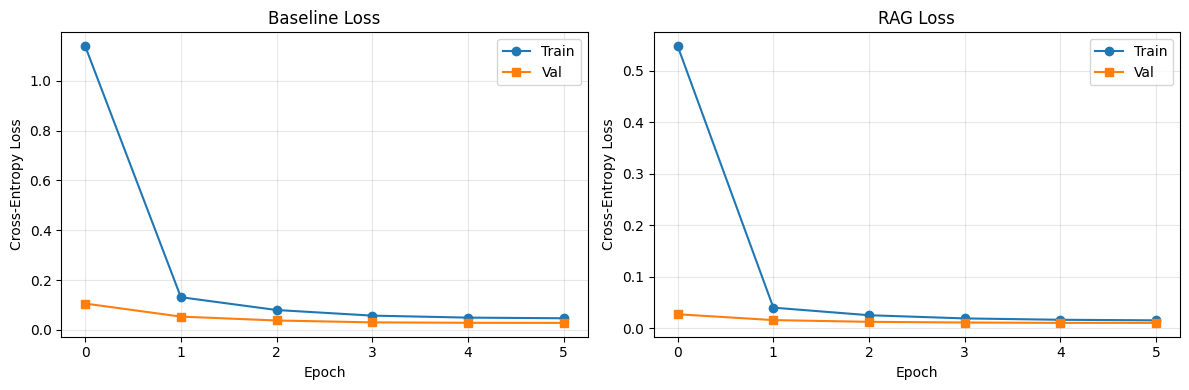

Saved: training_curves.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, hist, title in zip(
    axes, [baseline_history, rag_history], ["Baseline Loss", "RAG Loss"]
):
    ax.plot(hist["train"], marker="o", label="Train")
    ax.plot(hist["val"],   marker="s", label="Val")
    ax.set_title(title); ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-Entropy Loss")
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Saved: training_curves.png")

# Something

In [ ]:
print("\n" + "="*70)
print(f"{'Metric':<35} {'Baseline':>10} {'RAG':>10} {'Delta':>10} {'OK?':>4}")
print("="*70)
for metric in res_baseline:
    b        = res_baseline[metric]
    r        = res_rag[metric]
    d        = r - b
    want_up  = metric.endswith("(up)")
    improved = (d > 0 and want_up) or (d < 0 and not want_up)
    arrow    = "^" if d >= 0 else "v"
    tick     = "YES" if improved else "NO"
    print(f"{metric:<35} {b:>9}% {r:>9}% {arrow}{abs(d):>7.2f}%  {tick}")
print("="*70)

In [ ]:
print("res_baseline:", res_baseline)
print("res_rag:     ", res_rag)

# YOUR NOVEL CONTRIBUTION: Top-K Ablation


NOVEL CONTRIBUTION: Top-K Retrieval Ablation

Encoding all test queries (once for all K values)...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]


K = 1 ...


Eval K=1: 100%|██████████| 28/28 [02:41<00:00,  5.78s/it]



K = 3 ...


...


K = 5 ...


Eval K=5: 100%|██████████| 28/28 [02:01<00:00,  4.33s/it]



K = 10 ...


Eval K=10: 100%|██████████| 28/28 [02:54<00:00,  6.23s/it]



K                 Intent EM (up)         Bag of Slots (up)  Hallucinated Slot Types   Hallucinated Intents (do
--------------------------------------------------------------------------------------------------------------
1                         57.45%                    12.68%                    14.73%                     0.00%
3                         73.35%                    29.14%                     0.22%                     0.00%
5                         74.80%                    34.51%                     0.00%                     0.00%
10                        72.79%                    35.66%                     0.00%                     0.00%


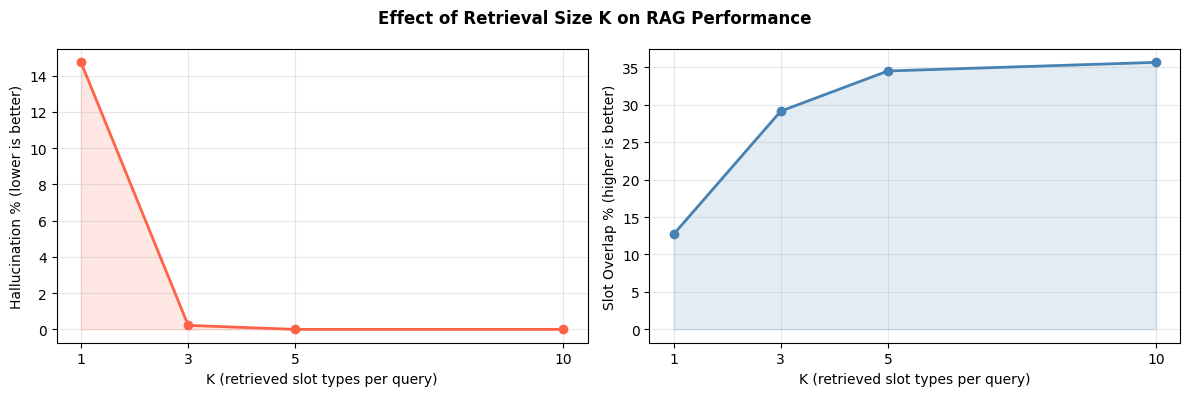

Saved: k_ablation.png

Optimal K for hallucination reduction: K = 5

All checkpoints and plots saved:
  ckpt_baseline/     baseline model
  ckpt_rag/          RAG model
  retriever_ckpt/    fine-tuned retriever
  training_curves.png
  k_ablation.png


In [27]:
# Paper gap: they fix K (number of retrieved items) and never
# study its effect. We ablate K = {1, 3, 5, 10} on the RAG model.
# This tells us the sweet spot — too few items = low recall,
# too many = noisy prompt confusing the LLM.
# ================================================================
print("\n" + "="*60)
print("NOVEL CONTRIBUTION: Top-K Retrieval Ablation")
print("="*60)

K_VALUES = [1, 3, 5, 10]
MAX_K    = max(K_VALUES)

print("\nEncoding all test queries (once for all K values)...")
test_q_embs = ret_model.encode(
    [ex["text"] for ex in test_data],
    batch_size=128, show_progress_bar=True, convert_to_numpy=True,
).astype(np.float32)

_, all_slot_idxs   = slot_index.search(test_q_embs, MAX_K)
_, all_intent_idxs = intent_index.search(test_q_embs, 3)

k_results = {}
for k in K_VALUES:
    print(f"\nK = {k} ...")
    prompts_k = [
        build_rag_prompt(
            test_data[i]["text"],
            [SLOT_VOCAB[j]   for j in all_slot_idxs[i][:k]],
            [INTENT_VOCAB[j] for j in all_intent_idxs[i]],
        )
        for i in range(len(test_data))
    ]
    k_results[k] = evaluate(rag_model, test_data, prompts_k, f"K={k}")

# Print ablation table
metrics = list(k_results[K_VALUES[0]].keys())
col_w   = 26
print("\n" + "="*(6 + col_w * len(metrics)))
print(f"{'K':<6}" + "".join(f"{m[:col_w-2]:>{col_w}}" for m in metrics))
print("-"*(6 + col_w * len(metrics)))
for k, res in k_results.items():
    print(f"{k:<6}" + "".join(f"{v:>{col_w-1}.2f}%" for v in res.values()))
print("="*(6 + col_w * len(metrics)))

# Plot hallucination and slot overlap vs K
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ks = list(k_results.keys())
for ax, metric, color, ylabel in zip(
    axes,
    ["Hallucinated Slot Types (down)", "Bag of Slots (up)"],
    ["tomato", "steelblue"],
    ["Hallucination % (lower is better)", "Slot Overlap % (higher is better)"],
):
    vals = [k_results[k][metric] for k in ks]
    ax.plot(ks, vals, marker="o", color=color, linewidth=2)
    ax.fill_between(ks, vals, alpha=0.15, color=color)
    ax.set_xlabel("K (retrieved slot types per query)")
    ax.set_ylabel(ylabel)
    ax.set_xticks(ks)
    ax.grid(alpha=0.3)

plt.suptitle("Effect of Retrieval Size K on RAG Performance", fontweight="bold")
plt.tight_layout()
plt.savefig("k_ablation.png", dpi=150)
plt.show()
print("Saved: k_ablation.png")

optimal_k = min(k_results, key=lambda k: k_results[k]["Hallucinated Slot Types (down)"])
print(f"\nOptimal K for hallucination reduction: K = {optimal_k}")
print("\nAll checkpoints and plots saved:")
print("  ckpt_baseline/     baseline model")
print("  ckpt_rag/          RAG model")
print("  retriever_ckpt/    fine-tuned retriever")
print("  training_curves.png")
print("  k_ablation.png")

In [28]:
# ============================================================
# COLLECT & DOWNLOAD ALL RESULTS AS ZIP
# ============================================================
import os, json, zipfile
from datetime import datetime
from pathlib import Path

timestamp  = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_ZIP = f"experiment_results_{timestamp}.zip"

ITEMS_TO_COLLECT = [
    "ckpt_baseline",
    "ckpt_rag",
    "retriever_ckpt",
    "training_curves.png",
    "k_ablation.png",
    "GenAI_1_.ipynb",
]

# Auto-save metrics from memory if available
try:
    metrics = {"baseline": res_baseline, "rag": res_rag}
    if "k_results" in dir():
        metrics["k_ablation"] = {str(k): v for k, v in k_results.items()}
    with open("metrics_summary.json", "w") as f:
        json.dump(metrics, f, indent=2, default=str)
    ITEMS_TO_COLLECT.append("metrics_summary.json")
    print("✔ metrics_summary.json saved")
except Exception as e:
    print(f"ℹ Could not save metrics: {e}")

# Build ZIP
missing, included = [], []
with zipfile.ZipFile(OUTPUT_ZIP, "w", zipfile.ZIP_DEFLATED) as zf:
    for item in ITEMS_TO_COLLECT:
        path = Path(item)
        if not path.exists():
            missing.append(item)
            continue
        if path.is_file():
            zf.write(path, arcname=item)
            print(f"  ✔ {item} ({path.stat().st_size/1024:,.0f} KB)")
            included.append(item)
        elif path.is_dir():
            for file in sorted(path.rglob("*")):
                if file.is_file():
                    zf.write(file, arcname=str(file))
                    print(f"  ✔ {str(file)} ({file.stat().st_size/1024:,.0f} KB)")
            included.append(item)

zip_size = Path(OUTPUT_ZIP).stat().st_size / (1024*1024)
print(f"\n{'='*50}")
print(f"ZIP : {OUTPUT_ZIP}  ({zip_size:.2f} MB)")
print(f"Included : {len(included)} items")
if missing:
    print(f"Skipped  : {missing}")
print(f"{'='*50}")

# Auto-download in Colab
from google.colab import files
files.download(OUTPUT_ZIP)

✔ metrics_summary.json saved
  ✔ ckpt_baseline/README.md (5 KB)
  ✔ ckpt_baseline/adapter_config.json (1 KB)
  ✔ ckpt_baseline/adapter_model.safetensors (6,932 KB)
  ✔ ckpt_rag/README.md (5 KB)
  ✔ ckpt_rag/adapter_config.json (1 KB)
  ✔ ckpt_rag/adapter_model.safetensors (6,932 KB)
  ✔ retriever_ckpt/final/1_Pooling/config.json (0 KB)
  ✔ retriever_ckpt/final/README.md (12 KB)
  ✔ retriever_ckpt/final/config.json (1 KB)
  ✔ retriever_ckpt/final/config_sentence_transformers.json (0 KB)
  ✔ retriever_ckpt/final/model.safetensors (427,703 KB)
  ✔ retriever_ckpt/final/modules.json (0 KB)
  ✔ retriever_ckpt/final/sentence_bert_config.json (0 KB)
  ✔ retriever_ckpt/final/tokenizer.json (695 KB)
  ✔ retriever_ckpt/final/tokenizer_config.json (0 KB)
  ✔ training_curves.png (56 KB)
  ✔ k_ablation.png (63 KB)
  ✔ metrics_summary.json (1 KB)

ZIP : experiment_results_20260419_143328.zip  (399.00 MB)
Included : 6 items
Skipped  : ['GenAI_1_.ipynb']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>